In [1]:
# load libraies

%run py_libraries.py

/Users/4476224/.local/lib/python3.8/site-packages/tensorflow_addons/utils/ensure_tf_install.py:53: UserWarning: Tensorflow Addons supports using Python ops for all Tensorflow versions above or equal to 2.6.0 and strictly below 2.9.0 (nightly versions are not supported). 
 The versions of TensorFlow you are currently using is 2.13.0 and is not supported. 
Some things might work, some things might not.
If you were to encounter a bug, do not file an issue.
If you want to make sure you're using a tested and supported configuration, either change the TensorFlow version or the TensorFlow Addons's version. 
You can find the compatibility matrix in TensorFlow Addon's readme:
https://github.com/tensorflow/addons
  warnings.warn(


Instructions for updating:
non-resource variables are not supported in the long term


In [2]:
# loading utility files

from utility.sv_fig2 import savefig

In [3]:
# load original data

pd.set_option('display.max_columns', None)
pd.set_option('display.max_row', None)

# load data
X_train = pd.read_csv('data/norm_X_train_Yes_No.csv')
X_test = pd.read_csv('data/norm_X_test_Yes_No.csv')
y_train = pd.read_csv('data/y_train_Yes_No.csv')
y_test = pd.read_csv('data/y_test_Yes_No.csv')


print(X_train.shape)

(74, 15)


In [4]:
X_train.head()

,Age_at_Surgery,Race,Surgery,Smoker,BMI,NAC,cT,pT,cT_or_pT,pN,Bx_Histology,Histology,Sample_weight,Tumor_digest_count,Fragments_plated
0,77.0,1.0,1.0,0.0,23.17,1.0,4.0,9.0,9.0,0.0,1.0,1.0,0.84,3020000.0,6.0
1,81.0,1.0,2.0,1.0,28.58,NaN,1.0,NaN,1.0,NaN,1.0,11.0,0.18,1420000.0,9.0
2,84.0,1.0,1.0,0.0,28.11,0.0,NaN,9.0,9.0,4.0,4.0,6.0,0.07,350000.0,12.0
3,70.0,1.0,1.0,0.0,28.10,0.0,4.0,8.0,8.0,0.0,1.0,4.0,3.57,55000000.0,24.0
4,45.0,1.0,2.0,0.0,22.11,NaN,2.0,NaN,2.0,NaN,1.0,1.0,1.31,7160000.0,18.0


In [5]:
# # load imputed data

# pd.set_option('display.max_columns', None)
# pd.set_option('display.max_row', None)

# # load data
# data = pd.read_csv('data/Xy_Yes_No_md.csv')

# print(data.shape)

In [6]:
# # Data
# X_train = data.drop(columns=['OverallTILGrowth'])
# y_train = data['OverallTILGrowth']

In [7]:
Xy_Yes_No = pd.concat([X_train, y_train], axis=1)

In [8]:
print(X_train.columns.tolist())

['Age_at_Surgery', 'Race', 'Surgery', 'Smoker', 'BMI', 'NAC', 'cT', 'pT', 'cT_or_pT', 'pN', 'Bx_Histology', 'Histology', 'Sample_weight', 'Tumor_digest_count', 'Fragments_plated']


In [9]:
# file A
file_A = Xy_Yes_No.copy()

In [10]:
# compare imputation for Yes in file_A


file_A2 = file_A[file_A["OverallTILGrowth"] == 1]

In [11]:
#file B

file_B = pd.read_csv('output_train.csv')

In [12]:
# compare imputation for Yes in file_B


file_B2 = file_B[file_B["OverallTILGrowth"] == 1]

In [13]:


# mask of missing values in A
mask = file_A.isna()

# values that were imputed
imputed_values = file_B[mask]

In [14]:
# print(file_B.isna().sum())

In [15]:
comparison = []

for col in file_A.columns:
    if file_A[col].isna().sum() > 0:
        original = file_A[col].dropna()
        imputed = file_B[col][mask[col]]
        num_miss = len(imputed)
        print(imputed)
        
        comparison.append({
            'column': col,
            'Training_cohort_mean': original.mean(),
            'Imputed_data_mean': imputed.mean(),
            'Training_cohort_std': original.std(),
            'Imputed_data_std': imputed.std(),
            'Num_of_imputed_data': num_miss
        })

pd.DataFrame(comparison)

22    34.688695
38    21.051999
68    35.336983
Name: BMI, dtype: float64
1    0.0
4    0.0
Name: NAC, dtype: float64
2      4.0
19    10.0
27     7.0
37    10.0
44    10.0
62     7.0
Name: cT, dtype: float64
1      1.0
4      3.0
16     1.0
18     6.0
23    11.0
25     9.0
28     8.0
30     1.0
36     9.0
42     6.0
45     3.0
52     9.0
54     9.0
64     9.0
72     1.0
Name: pT, dtype: float64
1     1.0
4     4.0
16    0.0
18    0.0
20    1.0
22    0.0
23    0.0
25    0.0
28    0.0
30    0.0
35    0.0
36    0.0
39    0.0
42    0.0
45    1.0
50    0.0
52    0.0
54    0.0
60    0.0
61    0.0
63    0.0
64    0.0
72    0.0
Name: pN, dtype: float64
23    1.0
39    1.0
Name: Bx_Histology, dtype: float64
23    1.0
43    1.0
Name: Histology, dtype: float64


,column,Training_cohort_mean,Imputed_data_mean,Training_cohort_std,Imputed_data_std,Num_of_imputed_data
0,BMI,29.189296,30.359226,7.820292,8.066810,3
1,NAC,0.444444,0.000000,0.500391,0.000000,2
2,cT,4.058824,8.000000,2.278271,2.449490,6
3,pT,6.983051,5.733333,3.436576,3.692979,15
4,pN,0.725490,0.304348,1.201306,0.875670,23
5,Bx_Histology,2.041667,1.000000,2.260733,0.000000,2
6,Histology,2.819444,1.000000,3.194742,0.000000,2


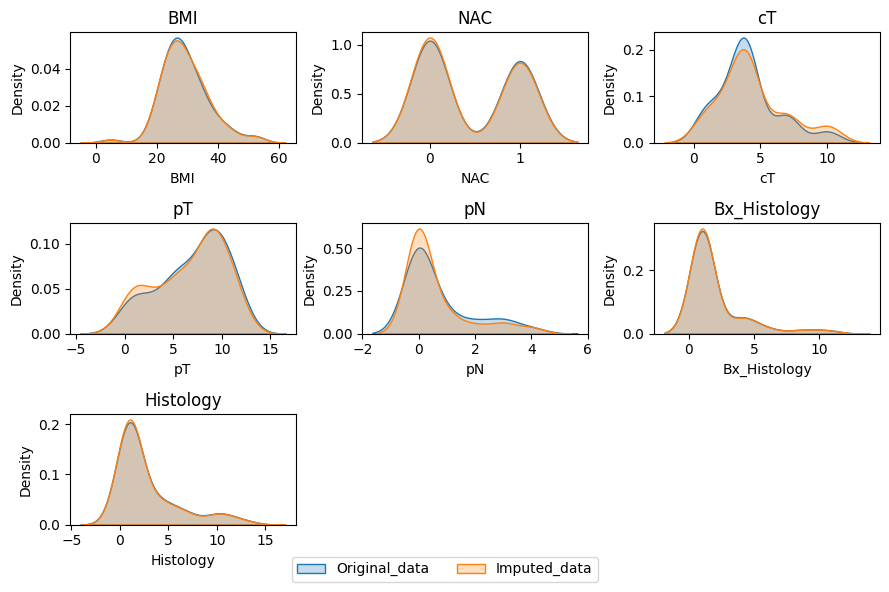

In [17]:
# comparison original vs imputed
import math

cols = ['BMI', 'NAC', 'cT', 'pT', 'pN', 'Bx_Histology', 'Histology',]
n_cols = 3
n_rows = math.ceil(len(cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(3*n_cols, 2*n_rows))
axes = axes.flatten()

for i, col in enumerate(cols):
    sns.kdeplot(file_A[col], label='Original_data', fill=True, ax=axes[i])
    sns.kdeplot(file_B[col], label='Imputed_data', fill=True, ax=axes[i])
    axes[i].set_title(col)
    # axes[i].legend()   # Remove this

# remove unused subplots (if any)
for j in range(len(cols), len(axes)):
    fig.delaxes(axes[j])

handles, labels = axes[0].get_legend_handles_labels()

fig.legend(handles, labels, loc='lower center', ncol=2, bbox_to_anchor=(0.5, 0.01))
plt.tight_layout(rect=[0, 0.02, 1, 1])

# plt.show()
savefig('./figs/Yes_No_den', dpi=600, quality=100)

In [18]:
# test

In [19]:
Xy_Yes_No_tt = pd.concat([X_test, y_test], axis=1)

In [20]:
# file A_tt
file_A_tt = Xy_Yes_No_tt.copy()

In [21]:
# compare imputation for Yes in file_A_tt


file_A2_tt = file_A_tt[file_A_tt["OverallTILGrowth"] == 1]

In [22]:
#file B_tt

file_B_tt = pd.read_csv('output_test.csv')

In [23]:
# compare imputation for Yes in file_B_tt


file_B2_tt = file_B_tt[file_B_tt["OverallTILGrowth"] == 1]

In [24]:


# mask of missing values in A_tt
mask_tt = file_A_tt.isna()

# values that were imputed
imputed_values_tt = file_B_tt[mask_tt]

In [25]:
comparison_tt = []

for col in file_A_tt.columns:
    if file_A_tt[col].isna().sum() > 0:
        original_tt = file_A_tt[col].dropna()
        imputed_tt = file_B_tt[col][mask_tt[col]]
        num_miss_tt = len(imputed_tt)
        print(imputed_tt)
        
        comparison_tt.append({
            'column': col,
            'Testing_cohort_mean': original_tt.mean(),
            'Imputed_data_mean': imputed_tt.mean(),
            'Testing_cohort_std': original_tt.std(),
            'Imputed_data_std': imputed_tt.std(),
            'Num_of_imputed_data': num_miss_tt
        })

pd.DataFrame(comparison_tt)

22    3.555427
Name: BMI, dtype: float64
4    0.0
Name: NAC, dtype: float64
4      7.0
29     1.0
31    10.0
Name: cT, dtype: float64
2     6.0
3     0.0
10    1.0
13    6.0
17    1.0
20    6.0
Name: pT, dtype: float64
0     0.0
2     0.0
3     0.0
10    0.0
13    0.0
17    0.0
20    0.0
25    0.0
26    3.0
31    0.0
Name: pN, dtype: float64
30    4.0
Name: Histology, dtype: float64


,column,Testing_cohort_mean,Imputed_data_mean,Testing_cohort_std,Imputed_data_std,Num_of_imputed_data
0,BMI,29.650000,3.555427,7.228947,NaN,1
1,NAC,0.290323,0.000000,0.461414,NaN,1
2,cT,3.896552,6.000000,2.425237,4.582576,3
3,pT,5.653846,3.333333,3.794125,2.943920,6
4,pN,0.363636,0.300000,0.789542,0.948683,10
5,Histology,2.741935,4.000000,2.555618,NaN,1


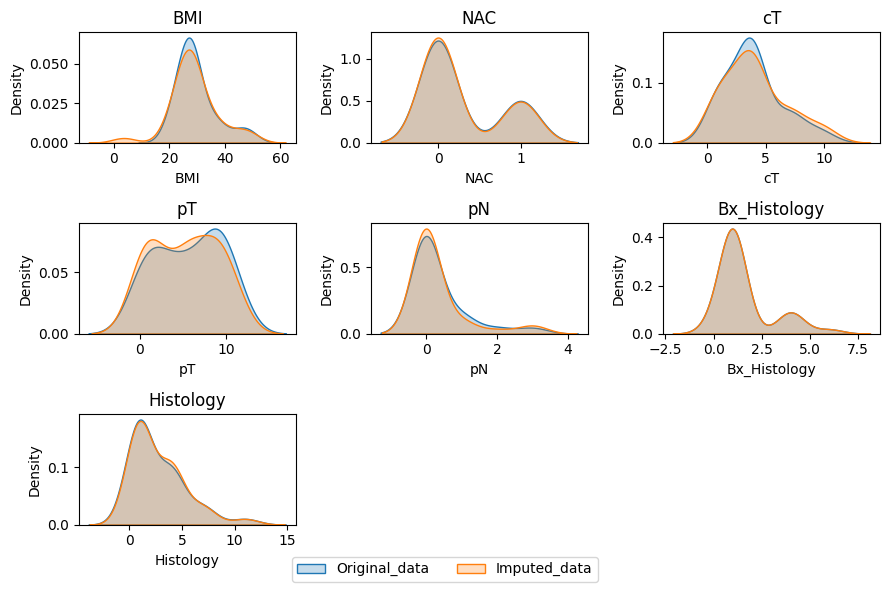

In [27]:
# comparison original vs imputed
import math

cols = ['BMI', 'NAC', 'cT', 'pT', 'pN', 'Bx_Histology', 'Histology',]
n_cols = 3
n_rows = math.ceil(len(cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(3*n_cols, 2*n_rows))
axes = axes.flatten()

for i, col in enumerate(cols):
    sns.kdeplot(file_A_tt[col], label='Original_data', fill=True, ax=axes[i])
    sns.kdeplot(file_B_tt[col], label='Imputed_data', fill=True, ax=axes[i])
    axes[i].set_title(col)
    # axes[i].legend()   # Remove this

# remove unused subplots (if any)
for j in range(len(cols), len(axes)):
    fig.delaxes(axes[j])

handles, labels = axes[0].get_legend_handles_labels()

fig.legend(handles, labels, loc='lower center', ncol=2, bbox_to_anchor=(0.5, 0.01))
plt.tight_layout(rect=[0, 0.02, 1, 1])

# plt.show()
savefig('./figs/Yes_No_den_test',dpi=600,quality=100)